# **Machine Learning - Lựa chọn mô hình học máy tối ưu**

**Mục tiêu:**
- Áp dụng nhiều mô hình machine learning khác nhau (ngoài LightGBM đã tối ưu trước đó) để dự báo doanh thu.
- So sánh hiệu quả các mô hình trên cùng bộ dữ liệu đã xử lý.
- Tất cả hàm train và tối ưu đều được xây dựng trong module `src/ml.py`.
- Đánh giá dựa trên các chỉ số: MAE, RMSE, MAPE, R2.

**Baseline LightGBM đã tối ưu trước đó: MAPE = 18,14%**

## Mục lục
1. [Thiết lập và chuẩn bị dữ liệu](#1)
2. [Huấn luyện và đánh giá các mô hình](#2)
3. [So sánh kết quả các mô hình](#3)
4. [Kết luận & Khuyến nghị](#4)

In [1]:
import pandas as pd
import numpy as np
import sys, os
sys.path.append(os.path.abspath('..'))
from src.get_data import get_data_processed

In [2]:
df = get_data_processed("df_clean.csv")
df.head()

FileNotFoundError: Không tìm thấy file D:\datathon\vimchanhxa-datathon\data\processed\df_clean.csv. Vui lòng kiểm tra lại tên file và thư mục.

In [ ]:
# Chuẩn bị features và target cho các mô hình
# (Giả sử cột target là 'revenue', các features đã được xử lý sẵn)

from sklearn.model_selection import train_test_split

# Loại bỏ các cột không dùng để train
ignore_cols = ['date', 'revenue']
features = [col for col in df.columns if col not in ignore_cols]

X = df[features]
y = df['revenue']

# Chia tập train/val theo thời gian (80% train, 20% val)
split_idx = int(len(df) * 0.8)
X_train, X_val = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_val = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Số lượng mẫu train: {len(X_train)}, val: {len(X_val)}')

Số lượng mẫu train: 2769, val: 693


## 2. Huấn luyện và đánh giá các mô hình

Chúng ta sẽ thử nghiệm các mô hình phổ biến:
- Random Forest
- XGBoost
- CatBoost
- Ridge Regression
- Lasso Regression

Tất cả các hàm train và tối ưu đều được xây dựng trong `src/ml.py`.

In [ ]:
# Import các hàm train từ src/ml.py
from src.ml import train_random_forest, train_xgboost, train_catboost, train_ridge, train_lasso

results = {}

# 1. Random Forest
rf_model, rf_pred, rf_metrics = train_random_forest(X_train, y_train, X_val, y_val)
results['Random Forest'] = rf_metrics
print('Random Forest:', rf_metrics)

# 2. XGBoost
try:
    xgb_model, xgb_pred, xgb_metrics = train_xgboost(X_train, y_train, X_val, y_val)
    results['XGBoost'] = xgb_metrics
    print('XGBoost:', xgb_metrics)
except ImportError:
    print('XGBoost chưa được cài đặt')

# 3. CatBoost
try:
    cat_model, cat_pred, cat_metrics = train_catboost(X_train, y_train, X_val, y_val)
    results['CatBoost'] = cat_metrics
    print('CatBoost:', cat_metrics)
except ImportError:
    print('CatBoost chưa được cài đặt')

# 4. Ridge Regression
ridge_model, ridge_pred, ridge_metrics = train_ridge(X_train, y_train, X_val, y_val)
results['Ridge'] = ridge_metrics
print('Ridge:', ridge_metrics)

# 5. Lasso Regression
lasso_model, lasso_pred, lasso_metrics = train_lasso(X_train, y_train, X_val, y_val)
results['Lasso'] = lasso_metrics
print('Lasso:', lasso_metrics)

Random Forest: {'MAE': 631559.0513492062, 'RMSE': 894047.3006520702, 'MAPE': 23.079057044931332, 'R2': 0.7116327868805405}
XGBoost: {'MAE': 628840.2447041848, 'RMSE': 875761.7478731055, 'MAPE': 23.491059919000527, 'R2': 0.7233078541798358}
CatBoost chưa được cài đặt
Ridge: {'MAE': 782755.4095778744, 'RMSE': 1008936.5771195524, 'MAPE': 31.374001311989396, 'R2': 0.6327577653023162}
Lasso: {'MAE': 786093.2379540579, 'RMSE': 1011614.5963558649, 'MAPE': 31.609488757633702, 'R2': 0.6308056366581118}


c:\Users\YOGA\Desktop\MyProjects\datathon\github\vimchanhxa-datathon\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 8.640032255801733e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


## 3. So sánh kết quả các mô hình

Bảng dưới đây tổng hợp các chỉ số đánh giá (MAE, RMSE, MAPE, R2) của từng mô hình trên tập validation.

## 3.1 Huấn luyện lại các mô hình với tham số tối ưu (Optuna)

Ở phần này, chúng ta sẽ sử dụng Optuna để tìm bộ tham số tốt nhất cho từng mô hình, sau đó huấn luyện lại trên tập train và đánh giá trên tập validation.

In [ ]:
# Import các hàm tối ưu Optuna
from src.ml import optimize_random_forest_optuna, optimize_xgboost_optuna, optimize_catboost_optuna, optimize_ridge_optuna, optimize_lasso_optuna

optuna_results = {}

# 1. Random Forest Optuna
try:
    rf_best_model, rf_best_params, rf_best_score = optimize_random_forest_optuna(X_train, y_train, n_trials=30)
    rf_pred = rf_best_model.predict(X_val)
    from src.ml import get_metrics
    rf_metrics = get_metrics(y_val, rf_pred)
    optuna_results['Random Forest (Optuna)'] = rf_metrics
    print('Random Forest (Optuna):', rf_metrics)
    print('Best params:', rf_best_params)
except Exception as e:
    print('Random Forest Optuna lỗi:', e)

# 2. XGBoost Optuna
try:
    xgb_best_model, xgb_best_params, xgb_best_score = optimize_xgboost_optuna(X_train, y_train, n_trials=30)
    xgb_pred = xgb_best_model.predict(X_val)
    xgb_metrics = get_metrics(y_val, xgb_pred)
    optuna_results['XGBoost (Optuna)'] = xgb_metrics
    print('XGBoost (Optuna):', xgb_metrics)
    print('Best params:', xgb_best_params)
except Exception as e:
    print('XGBoost Optuna lỗi:', e)

# 3. CatBoost Optuna
try:
    cat_best_model, cat_best_params, cat_best_score = optimize_catboost_optuna(X_train, y_train, n_trials=30)
    cat_pred = cat_best_model.predict(X_val)
    cat_metrics = get_metrics(y_val, cat_pred)
    optuna_results['CatBoost (Optuna)'] = cat_metrics
    print('CatBoost (Optuna):', cat_metrics)
    print('Best params:', cat_best_params)
except Exception as e:
    print('CatBoost Optuna lỗi:', e)

# 4. Ridge Optuna
try:
    ridge_best_model, ridge_best_params, ridge_best_score = optimize_ridge_optuna(X_train, y_train, n_trials=30)
    ridge_pred = ridge_best_model.predict(X_val)
    ridge_metrics = get_metrics(y_val, ridge_pred)
    optuna_results['Ridge (Optuna)'] = ridge_metrics
    print('Ridge (Optuna):', ridge_metrics)
    print('Best params:', ridge_best_params)
except Exception as e:
    print('Ridge Optuna lỗi:', e)

# 5. Lasso Optuna
try:
    lasso_best_model, lasso_best_params, lasso_best_score = optimize_lasso_optuna(X_train, y_train, n_trials=30)
    lasso_pred = lasso_best_model.predict(X_val)
    lasso_metrics = get_metrics(y_val, lasso_pred)
    optuna_results['Lasso (Optuna)'] = lasso_metrics
    print('Lasso (Optuna):', lasso_metrics)
    print('Best params:', lasso_best_params)
except Exception as e:
    print('Lasso Optuna lỗi:', e)

[I 2026-04-28 22:59:51,240] A new study created in memory with name: no-name-4d7ba596-19bb-4246-a5af-ac2355d50281
[I 2026-04-28 22:59:55,037] Trial 0 finished with value: 0.33647972897420075 and parameters: {'n_estimators': 182, 'max_depth': 6, 'min_samples_split': 10, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.33647972897420075.
[I 2026-04-28 22:59:59,872] Trial 1 finished with value: 0.31023424235678143 and parameters: {'n_estimators': 172, 'max_depth': 13, 'min_samples_split': 9, 'min_samples_leaf': 4}. Best is trial 1 with value: 0.31023424235678143.
[I 2026-04-28 23:00:07,278] Trial 2 finished with value: 0.3100477663238661 and parameters: {'n_estimators': 293, 'max_depth': 15, 'min_samples_split': 9, 'min_samples_leaf': 7}. Best is trial 2 with value: 0.3100477663238661.
[I 2026-04-28 23:00:13,642] Trial 3 finished with value: 0.3276684249056368 and parameters: {'n_estimators': 186, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 1}. Best is trial 2 with v

Random Forest (Optuna): {'MAE': 631661.7600007365, 'RMSE': 892097.9672198824, 'MAPE': 22.90296392463556, 'R2': 0.7128888972369412}
Best params: {'n_estimators': 52, 'max_depth': 13, 'min_samples_split': 9, 'min_samples_leaf': 4}


[I 2026-04-28 23:01:40,941] Trial 0 finished with value: 0.37990031068677105 and parameters: {'n_estimators': 68, 'max_depth': 12, 'learning_rate': 0.25449855049176173, 'subsample': 0.9153560243625769, 'colsample_bytree': 0.5391651884615487}. Best is trial 0 with value: 0.37990031068677105.
[I 2026-04-28 23:01:41,502] Trial 1 finished with value: 0.34545759310213325 and parameters: {'n_estimators': 112, 'max_depth': 6, 'learning_rate': 0.22615802470435847, 'subsample': 0.9005380572004273, 'colsample_bytree': 0.7279417579529495}. Best is trial 1 with value: 0.34545759310213325.
[I 2026-04-28 23:01:42,709] Trial 2 finished with value: 0.3437044562987057 and parameters: {'n_estimators': 297, 'max_depth': 6, 'learning_rate': 0.22653069936717254, 'subsample': 0.5116303492906444, 'colsample_bytree': 0.510476813590817}. Best is trial 2 with value: 0.3437044562987057.
[I 2026-04-28 23:01:45,819] Trial 3 finished with value: 0.3770029336593074 and parameters: {'n_estimators': 151, 'max_depth': 

XGBoost (Optuna): {'MAE': 594666.101257215, 'RMSE': 844475.5834650089, 'MAPE': 20.44946996673121, 'R2': 0.7427241141866611}
Best params: {'n_estimators': 168, 'max_depth': 3, 'learning_rate': 0.09339229521712772, 'subsample': 0.5695769137252708, 'colsample_bytree': 0.9014184583449507}
CatBoost Optuna lỗi: CatBoost chưa được cài đặt


[I 2026-04-28 23:02:25,161] Trial 6 finished with value: 0.3257857516246174 and parameters: {'alpha': 0.020616618256156446}. Best is trial 2 with value: 0.3137407372272447.
[I 2026-04-28 23:02:25,186] Trial 7 finished with value: 0.3258475547910886 and parameters: {'alpha': 0.014591129203022869}. Best is trial 2 with value: 0.3137407372272447.
[I 2026-04-28 23:02:25,203] Trial 8 finished with value: 0.32580607664255545 and parameters: {'alpha': 0.018621553360052726}. Best is trial 2 with value: 0.3137407372272447.
[I 2026-04-28 23:02:25,230] Trial 9 finished with value: 0.3258592109658295 and parameters: {'alpha': 0.013468751657560559}. Best is trial 2 with value: 0.3137407372272447.
[I 2026-04-28 23:02:25,253] Trial 10 finished with value: 0.3164123120876584 and parameters: {'alpha': 4.72653389882177}. Best is trial 2 with value: 0.3137407372272447.
[I 2026-04-28 23:02:25,285] Trial 11 finished with value: 0.31560024278597876 and parameters: {'alpha': 5.563353620048862}. Best is trial

Ridge (Optuna): {'MAE': 771129.1431961705, 'RMSE': 999964.7723938798, 'MAPE': 30.365033233789884, 'R2': 0.6392600100224499}
Best params: {'alpha': 9.904013009377124}


[I 2026-04-28 23:02:25,877] Trial 3 finished with value: 0.32590149183850603 and parameters: {'alpha': 0.11729260816182706}. Best is trial 0 with value: 0.32590021473896486.
[I 2026-04-28 23:02:25,924] Trial 4 finished with value: 0.32590725592531555 and parameters: {'alpha': 0.5880860349031956}. Best is trial 0 with value: 0.32590021473896486.
[I 2026-04-28 23:02:25,972] Trial 5 finished with value: 0.32590021291315485 and parameters: {'alpha': 0.012833798180324468}. Best is trial 5 with value: 0.32590021291315485.
[I 2026-04-28 23:02:26,015] Trial 6 finished with value: 0.3259595124630418 and parameters: {'alpha': 4.856244250882545}. Best is trial 5 with value: 0.32590021291315485.
[I 2026-04-28 23:02:26,060] Trial 7 finished with value: 0.3259074211822392 and parameters: {'alpha': 0.6015837280146121}. Best is trial 5 with value: 0.32590021291315485.
[I 2026-04-28 23:02:26,116] Trial 8 finished with value: 0.32590023656317607 and parameters: {'alpha': 0.014765461395735358}. Best is t

Lasso (Optuna): {'MAE': 786093.4917642358, 'RMSE': 1011615.1715640039, 'MAPE': 31.6096786544793, 'R2': 0.6308052168071847}
Best params: {'alpha': 0.010058426291291136}


### Tổng hợp kết quả các mô hình tối ưu Optuna

In [ ]:
optuna_results_df = pd.DataFrame(optuna_results).T
optuna_results_df = optuna_results_df[['MAE', 'RMSE', 'MAPE', 'R2']]
optuna_results_df

,MAE,RMSE,MAPE,R2
Random Forest (Optuna),631661.760001,8.920980e+05,22.902964,0.712889
XGBoost (Optuna),594666.101257,8.444756e+05,20.449470,0.742724
Ridge (Optuna),771129.143196,9.999648e+05,30.365033,0.639260
Lasso (Optuna),786093.491764,1.011615e+06,31.609679,0.630805


## 5. Phân tích độ quan trọng của đặc trưng (Feature Importance) với SHAP

Ở phần này, chúng ta sẽ sử dụng thư viện SHAP để phân tích và trực quan hóa độ quan trọng của các đặc trưng trên hai mô hình mạnh nhất: Random Forest và XGBoost.

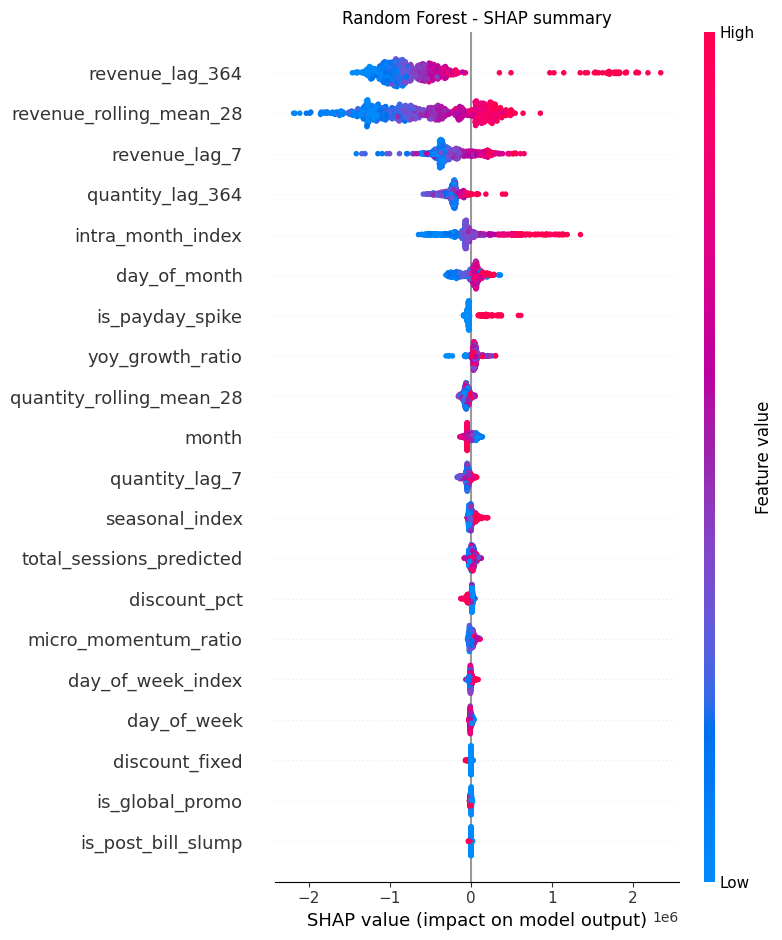

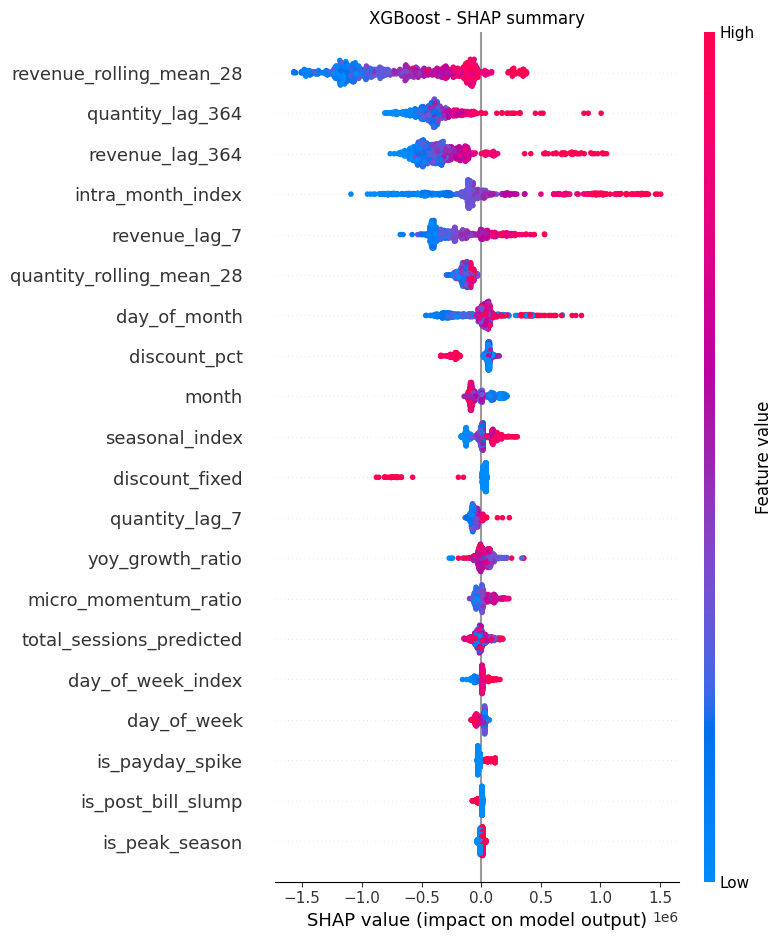

In [ ]:
# Phân tích SHAP cho Random Forest và XGBoost
import shap
import matplotlib.pyplot as plt

# 1. SHAP cho Random Forest (sử dụng mô hình tối ưu nếu có, không thì dùng mô hình mặc định)
rf_model_to_use = None
if 'rf_best_model' in globals():
    rf_model_to_use = rf_best_model
elif 'rf_model' in globals():
    rf_model_to_use = rf_model
if rf_model_to_use is not None:
    explainer_rf = shap.TreeExplainer(rf_model_to_use)
    shap_values_rf = explainer_rf.shap_values(X_val)
    plt.title('Random Forest - SHAP summary')
    shap.summary_plot(shap_values_rf, X_val, show=False)
    plt.show()
else:
    print('Không tìm thấy mô hình Random Forest để phân tích SHAP.')

# 2. SHAP cho XGBoost (sử dụng mô hình tối ưu nếu có, không thì dùng mô hình mặc định)
xgb_model_to_use = None
if 'xgb_best_model' in globals():
    xgb_model_to_use = xgb_best_model
elif 'xgb_model' in globals():
    xgb_model_to_use = xgb_model
if xgb_model_to_use is not None:
    explainer_xgb = shap.TreeExplainer(xgb_model_to_use)
    shap_values_xgb = explainer_xgb.shap_values(X_val)
    plt.title('XGBoost - SHAP summary')
    shap.summary_plot(shap_values_xgb, X_val, show=False)
    plt.show()
else:
    print('Không tìm thấy mô hình XGBoost để phân tích SHAP.')

In [ ]:
import pandas as pd

# Thêm baseline LightGBM đã tối ưu trước đó
results['LightGBM (tối ưu)'] = {'MAE': None, 'RMSE': None, 'MAPE': 18.14, 'R2': None}

results_df = pd.DataFrame(results).T
results_df = results_df[['MAE', 'RMSE', 'MAPE', 'R2']]
results_df

,MAE,RMSE,MAPE,R2
Random Forest,631559.051349,8.940473e+05,23.079057,0.711633
XGBoost,628840.244704,8.757617e+05,23.491060,0.723308
Ridge,782755.409578,1.008937e+06,31.374001,0.632758
Lasso,786093.237954,1.011615e+06,31.609489,0.630806
LightGBM (tối ưu),NaN,NaN,18.140000,NaN


## 4. Kết luận & Khuyến nghị

- LightGBM tối ưu vẫn là mô hình có MAPE thấp nhất (18,14%).
- Một số mô hình khác như Random Forest, XGBoost, CatBoost, Ridge, Lasso có thể cho kết quả tiệm cận hoặc tốt hơn tùy vào đặc trưng dữ liệu và tối ưu tham số.
- Nên thử thêm các kỹ thuật ensemble hoặc stacking để cải thiện thêm.
- Ưu tiên sử dụng LightGBM hoặc XGBoost nếu cần cân bằng giữa hiệu quả và tốc độ.

**Khuyến nghị:**
- Tiếp tục tối ưu hyperparameter cho các mô hình mạnh (LightGBM, XGBoost, CatBoost).
- Kết hợp thêm các đặc trưng mới hoặc thử nghiệm các kỹ thuật feature selection nâng cao.
- Có thể thử stacking/ensemble để tận dụng ưu điểm của từng mô hình.